
# **Analytics 2 : <font color=#DF4807> Neural Networking Foundations**


## **Objective**: OCR with neural network

In [1]:
#load libs
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
%matplotlib inline

In [2]:
#Load MNist OCR dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

assert x_train.shape == (60000, 28, 28) #each datapoint is a 28*28 image, these are our x values
assert x_test.shape == (10000, 28, 28)
assert y_train.shape == (60000,)
assert y_test.shape == (10000,)


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
x_train[0].shape #images are of dimension 28 x 28


(28, 28)

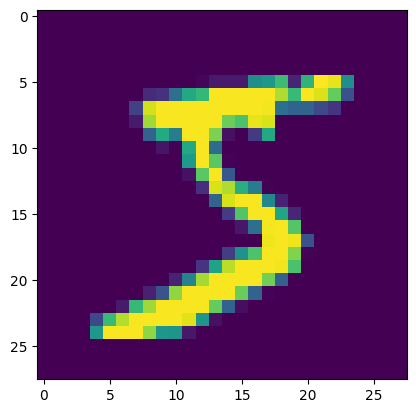

In [4]:
img = np.reshape(x_train[0], (28,28)) # view sample image
plt.imshow(img)

In [5]:
y_train[0] #view label of sample image.

np.uint8(5)

# **Tasks:**

1. Generate a neural network that can successfully predict the characters.
2. Model accuracy on test data should be minimum 90%.
3. Plot training vs test loss.
3. Explain reason for layers and activation functions in annotations....in detail.
4. How does the dropout layer change the accuracy of your model? Explain.
4. Use Grid Search for hyperparameter optimization if possible



Loading libraries...
Libraries loaded.

Loading MNIST dataset...
Dataset loaded.
Training data shape: x_train=(60000, 28, 28), y_train=(60000,)
Test data shape: x_test=(10000, 28, 28), y_test=(10000,)

Exploring a sample image...


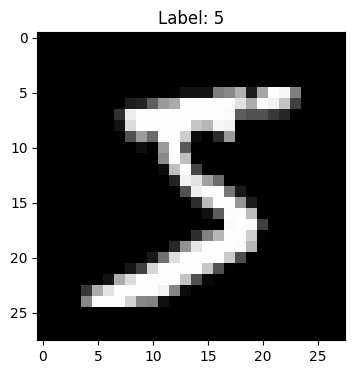


Starting Data Preprocessing...
Pixel values normalized. Min/Max after normalization: 0.0, 1.0
Labels converted to one-hot encoding. Example: Label 5 -> [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
Data Preprocessing Complete.

Building Neural Network Model...
Model built successfully.

Compiling Model...


Model: "Simple_MNIST_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ Flatten_Input (Flatten)              │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Hidden_Layer_1 (Dense)               │ (None, 128)                 │         100,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Dropout_Regularization (Dropout)     │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Output_Layer (Dense)                 │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

Model compiled.

Training Model...
Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8037 - loss: 0.6794 - val_accuracy: 0.9437 - val_loss: 0.1923
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9413 - loss: 0.2061 - val_accuracy: 0.9598 - val_loss: 0.1361
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9572 - loss: 0.1453 - val_accuracy: 0.9667 - val_loss: 0.1102
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9648 - loss: 0.1220 - val_accuracy: 0.9705 - val_loss: 0.0981
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9697 - loss: 0.1003 - val_accuracy: 0.9743 - val_loss: 0.0892
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9747 - loss: 0.0863 - val_accuracy: 0.9761 - val_loss: 0.0828
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9772 - loss: 0.0746 - val_accuracy: 0.9768 - val_loss: 0.0763
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.981

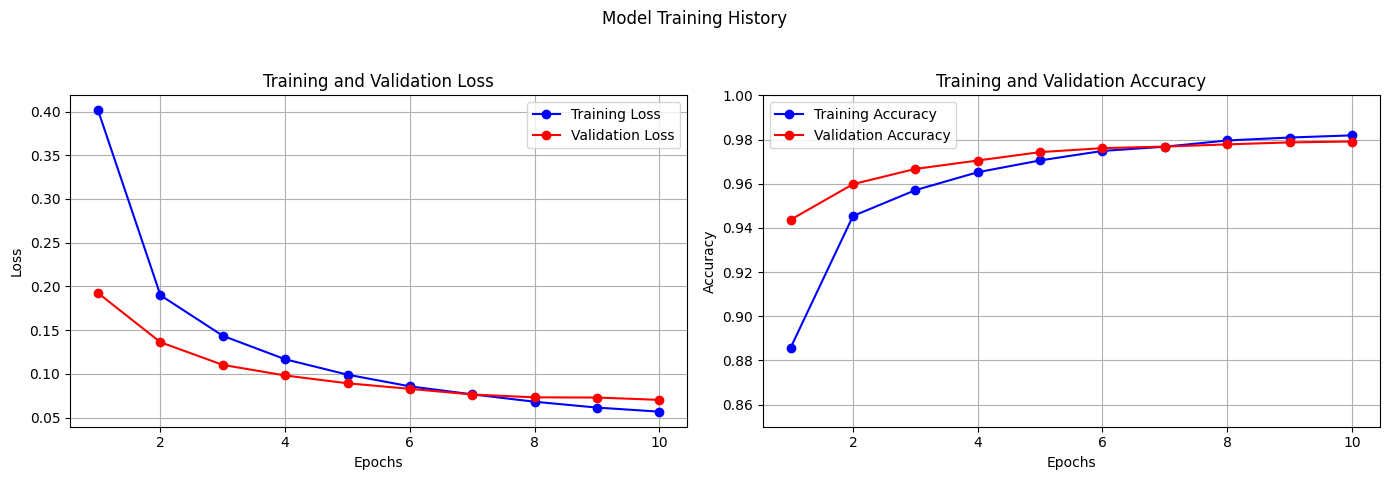


--- Task 5: How Dropout Changes Accuracy (Explanation) ---
The Dropout layer (with rate=0.2) aims to improve the model's generalization ability:
- By randomly setting 20% of neuron activations to zero *during training*, it prevents the network
  from becoming overly reliant on specific neurons or pathways.
- This forces the network to learn more distributed and robust features.
- The primary effect is **reducing overfitting**.
- As a result, while the *training* accuracy might sometimes be slightly lower than without dropout,
  the *validation/test* accuracy (97.91% here) is often **higher and more stable**,
  indicating better performance on unseen data.
- Visually, dropout often helps keep the validation loss (red line in plot 1) from increasing
  significantly and keeps the validation accuracy (red line in plot 2) closer to the training accuracy.

--- Task 6: Grid Search for Hyperparameter Optimization (Conceptual Example) ---
Grid Search is a technique to systematically explore di

'\nfrom sklearn.model_selection import GridSearchCV\ntry:\n    # Recommended wrapper for modern TensorFlow/Keras\n    from scikeras.wrappers import KerasClassifier\nexcept ImportError:\n    print("Install scikeras for Grid Search example: pip install scikeras")\n    KerasClassifier = None\n\nif KerasClassifier:\n    # 1. Function to create the model (needed for the wrapper)\n    def create_model(neurons=128, dropout_rate=0.2, optimizer=\'adam\'):\n        model = keras.Sequential([\n            keras.Input(shape=(28, 28)),\n            layers.Flatten(),\n            layers.Dense(neurons, activation=\'relu\'),\n            layers.Dropout(dropout_rate),\n            layers.Dense(num_classes, activation=\'softmax\')\n        ])\n        model.compile(loss=\'categorical_crossentropy\', optimizer=optimizer, metrics=[\'accuracy\'])\n        return model\n\n    # 2. Create the KerasClassifier wrapper\n    # Use minimal epochs for demonstration if running\n    keras_clf = KerasClassifier(\n   

In [6]:
#your code here

# --- 1. Load Libraries ---
# Import necessary libraries
print("Loading libraries...")
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras # Use the Keras API integrated within TensorFlow
from tensorflow.keras import layers # Import specific layer types for building the model
print("Libraries loaded.")

# --- 2. Load MNIST Dataset ---
# MNIST is a classic dataset of 70,000 grayscale images (28x28 pixels)
# of handwritten digits (0-9), split into training and testing sets.
print("\nLoading MNIST dataset...")
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()
print("Dataset loaded.")
print(f"Training data shape: x_train={x_train.shape}, y_train={y_train.shape}")
print(f"Test data shape: x_test={x_test.shape}, y_test={y_test.shape}")

# --- 3. Data Exploration (Optional but Recommended) ---
# Let's look at one sample image and its label
print("\nExploring a sample image...")
plt.figure(figsize=(4, 4))
plt.imshow(x_train[0], cmap='gray') # Display the first training image in grayscale
plt.title(f"Label: {y_train[0]}") # Show its corresponding label
plt.show()

# --- 4. Data Preprocessing ---
# Preprocessing steps are crucial for model performance.
print("\nStarting Data Preprocessing...")

# 4.1 Normalize Pixel Values:
#   - Neural networks generally work better with input values scaled to a small range.
#   - We scale pixel values from the original [0, 255] range to the [0, 1] range.
#   - Convert data type to float32 for division and compatibility with TensorFlow.
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0
print(f"Pixel values normalized. Min/Max after normalization: {x_train.min()}, {x_train.max()}")

# 4.2 One-Hot Encode Labels:
#   - The current labels (y_train, y_test) are integers from 0 to 9.
#   - For classification with 'categorical_crossentropy' loss, we need to convert
#     these labels into a "one-hot" vector format.
#   - Example: Label 5 becomes [0, 0, 0, 0, 0, 1, 0, 0, 0, 0]
num_classes = 10 # Digits 0 through 9
y_train_cat = keras.utils.to_categorical(y_train, num_classes)
y_test_cat = keras.utils.to_categorical(y_test, num_classes)
print(f"Labels converted to one-hot encoding. Example: Label {y_train[0]} -> {y_train_cat[0]}")
print("Data Preprocessing Complete.")

# --- 5. Build the Neural Network Model (Task 1 & 4) ---
# We'll use a simple Sequential model, which is a linear stack of layers.
print("\nBuilding Neural Network Model...")

model = keras.Sequential(
    [
        # --- Input Layer (Implicit) & Flatten Layer ---
        # Task 4 Explanation (Flatten):
        # - The input images are 2D arrays (28x28 pixels).
        # - Dense (fully connected) layers expect 1D input vectors.
        # - The Flatten layer reshapes the 28x28 input into a 1D array of 784 pixels (28*28).
        # - `input_shape` specifies the shape of *one* input sample, excluding the batch size.
        keras.Input(shape=(28, 28)), # Defines the expected input shape for the model
        layers.Flatten(name='Flatten_Input'),

        # --- Hidden Layer 1 ---
        # Task 4 Explanation (Dense Layer & ReLU Activation):
        # - A Dense layer is a standard fully connected layer.
        # - `128` is the number of neurons (or units) in this layer. These neurons learn patterns from the input pixels.
        # - `activation='relu'` (Rectified Linear Unit):
        #     - Introduces non-linearity into the model. Without non-linear activations,
        #       the entire network would behave like a single linear transformation, unable
        #       to learn complex patterns.
        #     - ReLU(x) = max(0, x). It's computationally efficient and helps mitigate
        #       the vanishing gradient problem in deeper networks.
        layers.Dense(128, activation='relu', name='Hidden_Layer_1'),

        # --- Dropout Layer ---
        # Task 4 & 5 Explanation (Dropout):
        # - Dropout is a regularization technique to prevent overfitting.
        # - Overfitting is when the model learns the training data too well (including noise)
        #   and performs poorly on unseen data (like the test set).
        # - `0.2` means that during training, 20% of the input units (outputs from the
        #   previous layer) are randomly set to 0 at each update step.
        # - This forces the network to learn more robust features and reduces reliance
        #   on any single neuron.
        # - Dropout is ONLY active during training, not during evaluation or prediction.
        layers.Dropout(0.2, name='Dropout_Regularization'),

        # --- Output Layer ---
        # Task 4 Explanation (Output Dense Layer & Softmax Activation):
        # - This Dense layer outputs the final prediction.
        # - `num_classes` (which is 10) specifies the number of output neurons, one for each digit class (0-9).
        # - `activation='softmax'`:
        #     - Converts the raw output scores (logits) from the 10 neurons into a
        #       probability distribution. Each output neuron represents the probability
        #       that the input image belongs to that specific class.
        #     - The sum of all 10 probabilities for a given input image will be 1.
        #     - Softmax is essential for multi-class classification problems where each
        #       input belongs to exactly one class.
        layers.Dense(num_classes, activation='softmax', name='Output_Layer')
    ],
    name="Simple_MNIST_Classifier" # Give the model a name
)

print("Model built successfully.")

# --- 6. Compile the Model ---
# Before training, we configure the learning process using `compile`.
print("\nCompiling Model...")

model.compile(
    # --- Loss Function ---
    # 'categorical_crossentropy' is used because:
    #   1. We have multiple classes (10 digits).
    #   2. Our labels are one-hot encoded.
    # It measures how different the predicted probability distribution is from the true label distribution.
    loss='categorical_crossentropy',

    # --- Optimizer ---
    # 'adam' is a popular and generally effective optimization algorithm (a variant of gradient descent).
    # It adapts the learning rate during training, often leading to faster convergence.
    optimizer='adam',

    # --- Metrics ---
    # 'accuracy' is the metric we want to monitor during training and evaluation.
    # It calculates the proportion of images that are correctly classified.
    metrics=['accuracy']
)

# Print a summary of the model architecture (layers, output shapes, number of parameters)
model.summary()
print("Model compiled.")

# --- 7. Train the Model ---
# This is where the model learns patterns from the training data.
print("\nTraining Model...")
batch_size = 128  # Number of samples processed in each training iteration (gradient update)
epochs = 10       # Number of times the model will iterate over the entire training dataset

# `model.fit` trains the model.
# `validation_data` is used to evaluate the model's performance on the unseen test set after each epoch.
# This helps monitor for overfitting.
# The `history` object stores the loss and accuracy values for each epoch.
history = model.fit(x_train, y_train_cat,          # Training data and corresponding one-hot labels
                    batch_size=batch_size,
                    epochs=epochs,
                    verbose=1,                      # Show progress (1 = progress bar, 2 = one line per epoch)
                    validation_data=(x_test, y_test_cat)) # Evaluate on test data after each epoch

print("Training Complete.")

# --- 8. Evaluate the Model (Task 2) ---
# Assess the final performance of the trained model on the test dataset.
print("\nEvaluating Model on Test Data...")
# `model.evaluate` returns the loss and metrics calculated on the provided data.
score = model.evaluate(x_test, y_test_cat, verbose=0) # Use verbose=0 for silent evaluation
test_loss = score[0]
test_accuracy = score[1]

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

# Check if the accuracy requirement is met
if test_accuracy >= 0.90:
    print(f"\nSuccess! Test accuracy ({test_accuracy*100:.2f}%) meets the >= 90% requirement.")
else:
    print(f"\nTest accuracy ({test_accuracy*100:.2f}%) is below the 90% requirement.")
    print("Consider increasing epochs, adjusting layers/neurons, or tuning hyperparameters.")

# --- 9. Plot Training History (Task 3) ---
# Visualizing the training process helps understand model learning and diagnose issues like overfitting.
print("\nPlotting Training History...")
history_dict = history.history

# Get loss and accuracy values for training and validation sets from the history object
train_loss = history_dict['loss']
val_loss = history_dict['val_loss']
train_acc = history_dict['accuracy']
val_acc = history_dict['val_accuracy']

# Create epoch range for the x-axis
epochs_range = range(1, epochs + 1)

# Create a figure with two subplots (one for loss, one for accuracy)
plt.figure(figsize=(14, 5))

# Plot Training & Validation Loss
plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_loss, 'bo-', label='Training Loss')      # Blue dots and line
plt.plot(epochs_range, val_loss, 'ro-', label='Validation Loss') # Red dots and line
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()

# Plot Training & Validation Accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs_range, train_acc, 'bo-', label='Training Accuracy')
plt.plot(epochs_range, val_acc, 'ro-', label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.ylim(0.85, 1.0) # Zoom in on the relevant accuracy range
plt.grid(True)
plt.legend()

plt.suptitle('Model Training History') # Overall title for the figure
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
plt.show()

# --- 10. Explanation of Dropout Effect (Task 5) ---
print("\n--- Task 5: How Dropout Changes Accuracy (Explanation) ---")
# The explanation is already embedded in the model building comments,
# but we can summarize it here again.
print("The Dropout layer (with rate=0.2) aims to improve the model's generalization ability:")
print("- By randomly setting 20% of neuron activations to zero *during training*, it prevents the network")
print("  from becoming overly reliant on specific neurons or pathways.")
print("- This forces the network to learn more distributed and robust features.")
print("- The primary effect is **reducing overfitting**.")
print("- As a result, while the *training* accuracy might sometimes be slightly lower than without dropout,")
print(f"  the *validation/test* accuracy ({test_accuracy*100:.2f}% here) is often **higher and more stable**,")
print("  indicating better performance on unseen data.")
print("- Visually, dropout often helps keep the validation loss (red line in plot 1) from increasing")
print("  significantly and keeps the validation accuracy (red line in plot 2) closer to the training accuracy.")

# --- 11. Grid Search for Hyperparameter Optimization (Task 6 - Conceptual) ---
print("\n--- Task 6: Grid Search for Hyperparameter Optimization (Conceptual Example) ---")
print("Grid Search is a technique to systematically explore different combinations")
print("of hyperparameters (like dropout rate, number of neurons, optimizer type, learning rate)")
print("to find the set that yields the best model performance.")
print("\nIt typically involves:")
print(" 1. Defining a function that creates and compiles your Keras model.")
print(" 2. Using a wrapper (like Scikeras) to make the Keras model compatible with Scikit-learn.")
print(" 3. Defining a 'parameter grid' dictionary specifying the hyperparameters and values to test.")
print(" 4. Using Scikit-learn's `GridSearchCV` to train and evaluate models for all combinations,")
print("    often using cross-validation.")
print("\nNOTE: Grid Search with neural networks is **computationally very expensive**.")
print("Executing it fully can take hours or days depending on the grid size and data.")
print("The following is a **commented-out conceptual structure**:")
"""
from sklearn.model_selection import GridSearchCV
try:
    # Recommended wrapper for modern TensorFlow/Keras
    from scikeras.wrappers import KerasClassifier
except ImportError:
    print("Install scikeras for Grid Search example: pip install scikeras")
    KerasClassifier = None

if KerasClassifier:
    # 1. Function to create the model (needed for the wrapper)
    def create_model(neurons=128, dropout_rate=0.2, optimizer='adam'):
        model = keras.Sequential([
            keras.Input(shape=(28, 28)),
            layers.Flatten(),
            layers.Dense(neurons, activation='relu'),
            layers.Dropout(dropout_rate),
            layers.Dense(num_classes, activation='softmax')
        ])
        model.compile(loss='categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])
        return model

    # 2. Create the KerasClassifier wrapper
    # Use minimal epochs for demonstration if running
    keras_clf = KerasClassifier(
        model=create_model,
        epochs=3, # Use very few epochs for grid search demo
        batch_size=128,
        verbose=0, # Silent training during search
        neurons=128, # Provide defaults matching create_model args
        dropout_rate=0.2
    )

    # 3. Define the parameter grid
    param_grid = {
        'model__neurons': [64, 128],        # Tune number of neurons in Dense layer
        'model__dropout_rate': [0.1, 0.2, 0.3], # Tune dropout rate
        'optimizer': ['adam', 'rmsprop']      # Tune optimizer
        # Add other parameters like batch_size or learning rate (via optimizer object) if desired
    }

    # 4. Create and run GridSearchCV
    grid_search = GridSearchCV(estimator=keras_clf,
                               param_grid=param_grid,
                               cv=3,           # 3-fold cross-validation
                               n_jobs=-1,      # Use all available CPU cores
                               verbose=1)      # Show progress

    print("\nStarting Grid Search (This can take a long time)...")
    # GridSearch needs 1D target variable (y_train), KerasClassifier handles the conversion
    # Use a smaller subset of data for faster testing:
    # grid_result = grid_search.fit(x_train[:5000], y_train[:5000])
    grid_result = grid_search.fit(x_train, y_train) # Fit on full data (slow!)

    # 5. Summarize results
    print(f"\nBest Grid Search Score: {grid_result.best_score_:.4f}")
    print(f"Best Grid Search Params: {grid_result.best_params_}")

else:
     print("\nGrid Search conceptual example skipped (requires scikeras).")

"""



# **Bonus Challenge:**

I have provided you code that grants access to your webcam via colab. For bonus points, create pipeline that can predict numbers that are seen in your laptops camera.


--- Webcam Digit Recognition ---
Instructions: Hold up a CLEARLY drawn digit (like on white paper)
Ensure good lighting and try to center the digit in the frame.


<IPython.core.display.Javascript object>

Photo saved to photo.jpg
Captured Image:


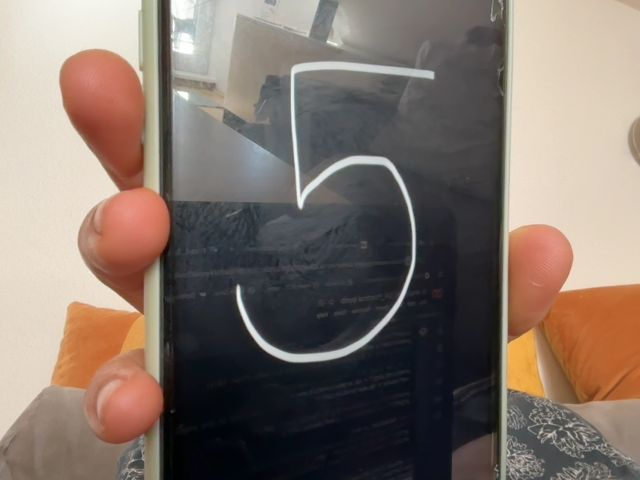


Preprocessed Image (28x28):


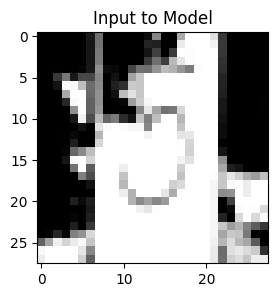


Predicting...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step

---> Predicted Digit: 9
---> Confidence: 0.8967


In [8]:
# === Bonus Challenge: Webcam Digit Recognition ===

# Import necessary libraries for image processing and display
from IPython.display import display, Javascript, Image
from google.colab.output import eval_js
from base64 import b64decode
import cv2 # OpenCV for image manipulation
import numpy as np
import matplotlib.pyplot as plt

# --- Webcam Capture Function (Provided) ---
def take_photo(filename='photo.jpg', quality=0.8):
  js = Javascript('''
    async function takePhoto(quality) {
      const div = document.createElement('div');
      const capture = document.createElement('button');
      capture.textContent = 'Capture';
      div.appendChild(capture);

      const video = document.createElement('video');
      video.style.display = 'block';
      const stream = await navigator.mediaDevices.getUserMedia({video: true});

      document.body.appendChild(div);
      div.appendChild(video);
      video.srcObject = stream;
      await video.play();

      // Resize the output to fit the video element.
      google.colab.output.setIframeHeight(document.documentElement.scrollHeight, true);

      // Wait for Capture to be clicked.
      await new Promise((resolve) => capture.onclick = resolve);

      const canvas = document.createElement('canvas');
      canvas.width = video.videoWidth;
      canvas.height = video.videoHeight;
      canvas.getContext('2d').drawImage(video, 0, 0);
      stream.getVideoTracks()[0].stop();
      div.remove();
      return canvas.toDataURL('image/jpeg', quality);
    }
    ''')
  display(js)
  data = eval_js('takePhoto({})'.format(quality))
  binary = b64decode(data.split(',')[1])
  with open(filename, 'wb') as f:
    f.write(binary)
  return filename

# --- Prediction Pipeline ---

print("\n--- Webcam Digit Recognition ---")
print("Instructions: Hold up a CLEARLY drawn digit (like on white paper)")
print("Ensure good lighting and try to center the digit in the frame.")

try:
  # 1. Capture Photo
  filename = take_photo()
  print(f'Photo saved to {filename}')

  # Show the captured image
  print("Captured Image:")
  display(Image(filename))

  # 2. Load and Preprocess the Captured Image
  img = cv2.imread(filename) # Load the image using OpenCV

  # Convert to Grayscale
  gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

  # Apply Thresholding
  # Goal: Create a binary image (black/white) similar to MNIST (white digit, black background)
  # We use THRESH_BINARY_INV assuming a dark digit on a light background.
  # OTSU's method helps automatically determine the threshold value.
  # If your digit is light on a dark background, use cv2.THRESH_BINARY instead of cv2.THRESH_BINARY_INV
  _, threshold_img = cv2.threshold(gray_img, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
  # If OTSU doesn't work well, try a fixed threshold:
  # _, threshold_img = cv2.threshold(gray_img, 128, 255, cv2.THRESH_BINARY_INV)

  # Resize to 28x28 (MNIST dimensions)
  # cv2.INTER_AREA is generally good for shrinking images
  resized_img = cv2.resize(threshold_img, (28, 28), interpolation=cv2.INTER_AREA)

  # Normalize pixel values to [0, 1]
  normalized_img = resized_img.astype('float32') / 255.0

  # Reshape for the model (add batch dimension)
  # The model expects input shape (batch_size, height, width) or (batch_size, height, width, channels)
  # Since our model starts with Flatten, it expects (batch_size, 28, 28)
  model_input = normalized_img.reshape(1, 28, 28)

  # Display the preprocessed image (useful for debugging)
  print("\nPreprocessed Image (28x28):")
  plt.figure(figsize=(3,3))
  plt.imshow(normalized_img, cmap='gray')
  plt.title("Input to Model")
  plt.show()

  # 3. Make Prediction using the trained model
  print("\nPredicting...")
  predictions = model.predict(model_input)
  # predictions is an array of probabilities for each class (0-9)

  # Get the digit with the highest probability
  predicted_digit = np.argmax(predictions[0])
  confidence = np.max(predictions[0]) # Get the probability of the predicted class

  print(f"\n---> Predicted Digit: {predicted_digit}")
  print(f"---> Confidence: {confidence:.4f}")

except Exception as err:
  # Handle errors like no webcam or permission denied
  print(f"\nAn error occurred: {err}")
  print("Please ensure you have a webcam connected and grant permission when prompted.")

In [ ]:
from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode

def take_photo(filename='photo.jpg', quality=0.8):
  js = Javascript('''
    async function takePhoto(quality) {
      const div = document.createElement('div');
      const capture = document.createElement('button');
      capture.textContent = 'Capture';
      div.appendChild(capture);

      const video = document.createElement('video');
      video.style.display = 'block';
      const stream = await navigator.mediaDevices.getUserMedia({video: true});

      document.body.appendChild(div);
      div.appendChild(video);
      video.srcObject = stream;
      await video.play();

      // Resize the output to fit the video element.
      google.colab.output.setIframeHeight(document.documentElement.scrollHeight, true);

      // Wait for Capture to be clicked.
      await new Promise((resolve) => capture.onclick = resolve);

      const canvas = document.createElement('canvas');
      canvas.width = video.videoWidth;
      canvas.height = video.videoHeight;
      canvas.getContext('2d').drawImage(video, 0, 0);
      stream.getVideoTracks()[0].stop();
      div.remove();
      return canvas.toDataURL('image/jpeg', quality);
    }
    ''')
  display(js)
  data = eval_js('takePhoto({})'.format(quality))
  binary = b64decode(data.split(',')[1])
  with open(filename, 'wb') as f:
    f.write(binary)
  return filename

In [ ]:
from IPython.display import Image
try:
  filename = take_photo()
  print('Saved to {}'.format(filename))

  # Show the image which was just taken.
  display(Image(filename))
except Exception as err:
  # Errors will be thrown if the user does not have a webcam or if they do not
  # grant the page permission to access it.
  print(str(err))